# Clean synthetic-noise verification

Displays selected examples where the surrogate segment is separated from the P arrival.


In [1]:
import os
import sys
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path(r"M:\Github\TFM_SeismicPhasePicker_ColombianAndesRegion")
sys.path.insert(0, str(REPO_ROOT / "src" / "preprocessing"))
sys.path.insert(0, str(REPO_ROOT / "src" / "labeling"))

import preprocessing_utils as pp
import consensus_utils as cu

_kw = cu.synth_noise.__kwdefaults__
PRE_A, PRE_B = _kw["pre_a"], _kw["pre_b"]
print(f"Tramo de ruido: {PRE_A/100:.0f}s a {PRE_B/100:.0f}s (P debe ser > {PRE_B/100:.0f}s)")

Tramo de ruido: 2s a 27s (P debe ser > 27s)


In [2]:
# Select examples with an accepted P after the source interval.
LABELING_DIR = REPO_ROOT / "data" / "processed" / "labeling"
files = sorted(glob.glob(str(LABELING_DIR / "labels_*.csv")))
labels = pd.concat([pd.read_csv(f, on_bad_lines="skip") for f in files], ignore_index=True)

eq = labels[(labels["category"] == "earthquake")
            & labels["p_time_s"].notna()
            & labels["s_time_s"].notna()
            & (labels["p_time_s"] > PRE_B / 100.0)
            & (labels["snr_p_db"] > 5.0)].copy()

print(f"Sismos limpios candidatos (P > {PRE_B/100:.0f}s, SNR_P > 5 dB): {len(eq)}")

# Prefer one clear example per station.
sel = (eq.sort_values("snr_p_db", ascending=False)
         .groupby("station_code").head(1)
         .sort_values("station_code")
         .reset_index(drop=True))
print(f"Estaciones seleccionadas: {len(sel)}")
print(sel[["station_code", "timestamp", "p_time_s", "s_time_s", "snr_p_db"]].head(10).to_string(index=False))

Sismos limpios candidatos (P > 27s, SNR_P > 5 dB): 22978
Estaciones seleccionadas: 22
station_code         timestamp  p_time_s  s_time_s  snr_p_db
        BRJC 2018.234.13.06.10     28.63     41.27     50.86
        CBOC 2023.244.02.18.55     29.85     42.08     50.38
         CHI 2023.134.06.03.58     30.91     37.81     54.34
         DBB 2025.291.07.39.37     68.99     71.30     51.17
       GUY2C 2019.045.21.09.32     29.62     41.10     49.89
        JAMC 2024.075.18.48.31     30.61     38.41     50.60
         MAL 2019.050.11.06.08     29.19     39.35     52.07
         NOR 2019.045.21.09.39     28.74     43.87     55.06
        ORTC 2021.333.07.53.29     31.03     45.87     57.99
         PAL 2023.261.23.57.13     31.12     39.90     54.45


In [3]:
def cargar_y_generar(row, seed):
    sta = row["station_code"]
    ts = str(row["timestamp"])
    station_dir = REPO_ROOT / "data" / "raw" / "waveforms" / sta
    arr = pp.load_window_array(station_dir, ts, sta, preprocess=True)
    if arr is None:
        return None
    rng = np.random.default_rng(seed)
    syn = cu.synth_noise(arr, pp.NPTS, rng=rng)
    return {"sta": sta, "ts": ts, "arr": arr, "syn": syn,
            "p_s": row["p_time_s"], "s_s": row["s_time_s"],
            "snr": row["snr_p_db"]}

resultados = []
for i, row in sel.head(8).iterrows():
    r = cargar_y_generar(row, 100 + i)
    if r is not None:
        resultados.append(r)

print(f"Cargadas y generadas: {len(resultados)} ventanas")

Cargadas y generadas: 8 ventanas


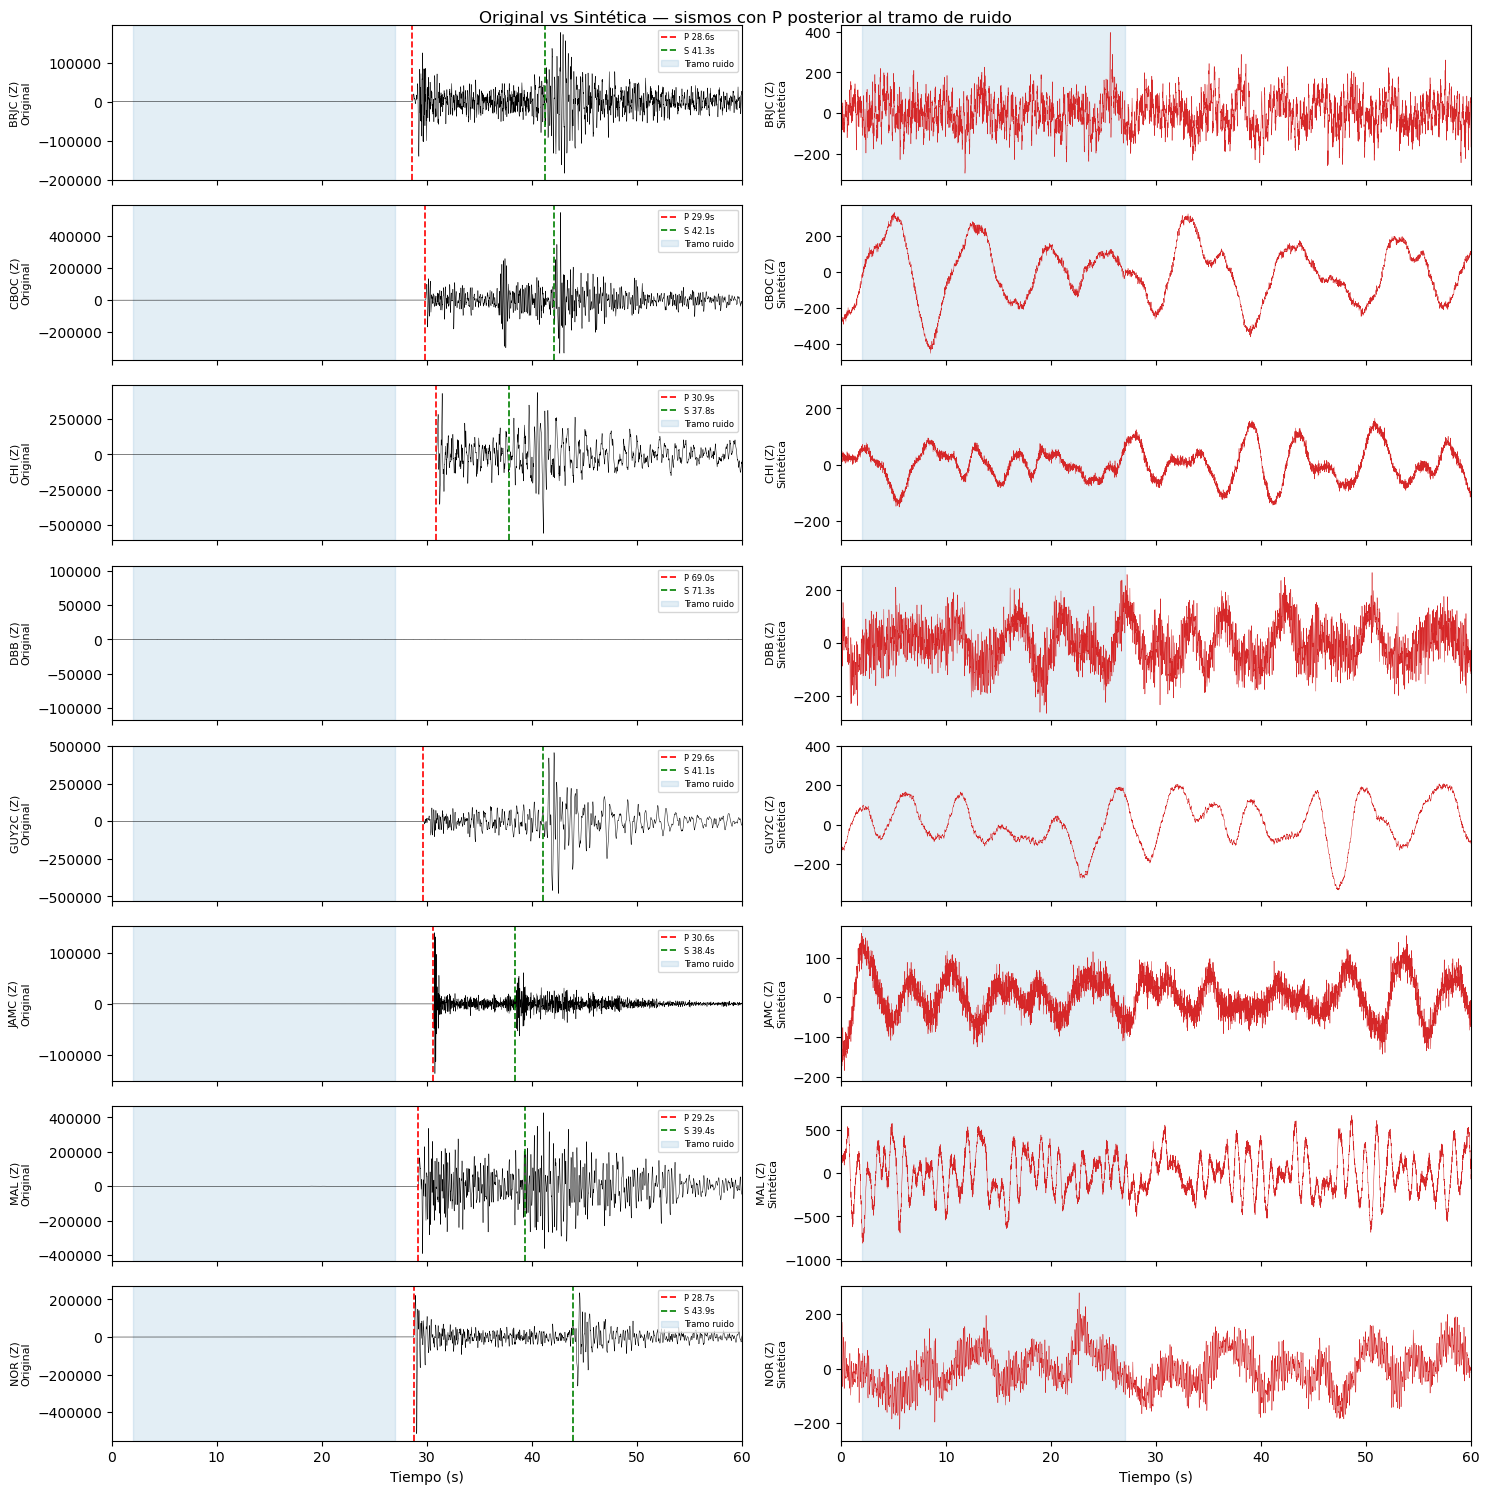

In [4]:
# Plot original and surrogate vertical traces over the first 60 s.
n = len(resultados)
fig, axes = plt.subplots(n, 2, figsize=(15, 1.9 * n), sharex=True)
if n == 1:
    axes = axes.reshape(1, 2)
t = np.arange(pp.NPTS) / 100.0

for i, r in enumerate(resultados):
    # Original
    ax0 = axes[i][0]
    ax0.plot(t, r["arr"][0], lw=0.35, color="k")
    ax0.axvline(r["p_s"], color="r", lw=1.2, ls="--", label=f"P {r['p_s']:.1f}s")
    if r["s_s"] == r["s_s"]:
        ax0.axvline(r["s_s"], color="g", lw=1.2, ls="--", label=f"S {r['s_s']:.1f}s")
    ax0.axvspan(PRE_A / 100, PRE_B / 100, color="tab:blue", alpha=0.12, label="Tramo ruido")
    ax0.set_ylabel(f"{r['sta']} (Z)\nOriginal", fontsize=8)
    ax0.set_xlim(0, 60)
    ax0.legend(fontsize=6, loc="upper right")

    # Surrogate
    ax1 = axes[i][1]
    ax1.plot(t, r["syn"][0], lw=0.35, color="tab:red")
    ax1.axvspan(PRE_A / 100, PRE_B / 100, color="tab:blue", alpha=0.12)
    ax1.set_ylabel(f"{r['sta']} (Z)\nSintética", fontsize=8)
    ax1.set_xlim(0, 60)

axes[-1][0].set_xlabel("Tiempo (s)")
axes[-1][1].set_xlabel("Tiempo (s)")
fig.suptitle("Original vs Sintética — sismos con P posterior al tramo de ruido", fontsize=12)
plt.tight_layout()
plt.show()

## Interpretation

The original trace marks the source segment and accepted arrivals; the paired synthetic trace shows the resulting surrogate. Inspect whether coherent arrival-like pulses persist near the marked P and S times.